<a href="https://colab.research.google.com/github/ipm06baarsadbarma-tech/IPM06012/blob/main/Baarsa.ITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

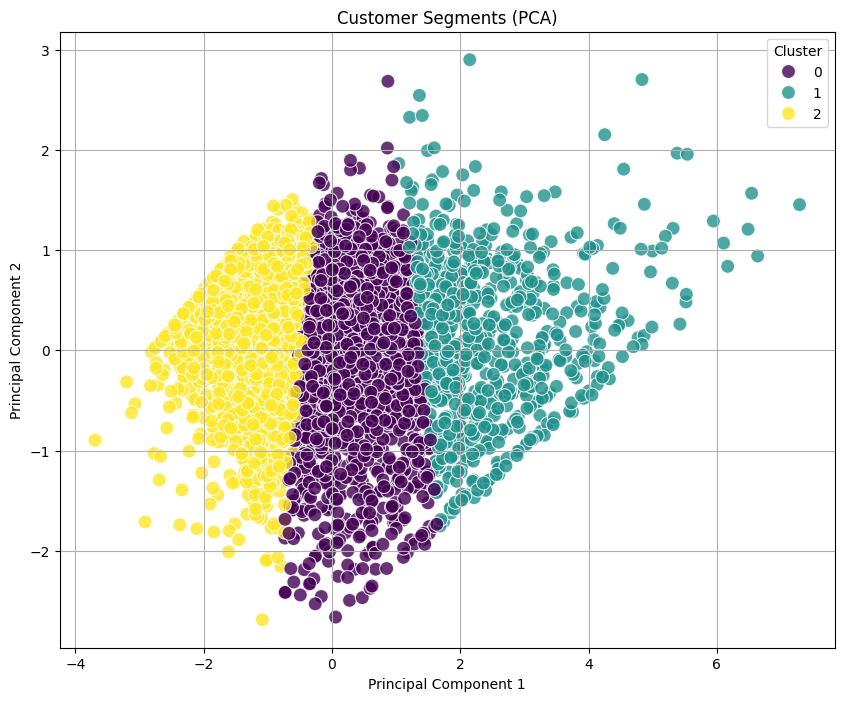

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']])
rfm_pca_df = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'], index=rfm_scaled_df.index)
rfm_pca_df['Cluster'] = rfm_scaled_df['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=rfm_pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
cluster_labels = {
    0: 'Loyal Customers',
    1: 'Churned/Lost Customers',
    2: 'At-Risk/Occasional Customers'
}

rfm_df['Customer_Segment'] = rfm_df['Cluster'].map(cluster_labels)
rfm_log['Customer_Segment'] = rfm_log['Cluster'].map(cluster_labels)
rfm_scaled_df['Customer_Segment'] = rfm_scaled_df['Cluster'].map(cluster_labels)

print('RFM DataFrame with Customer Segments:')
print(rfm_df.head())

RFM DataFrame with Customer Segments:
   CustomerID  Recency  Frequency  Monetary  Cluster  \
0     12346.0      326          1  77183.60        0   
1     12347.0        2          7   4310.00        1   
2     12348.0       75          4   1797.24        0   
3     12349.0       19          1   1757.55        0   
4     12350.0      310          1    334.40        2   

               Customer_Segment  
0               Loyal Customers  
1        Churned/Lost Customers  
2               Loyal Customers  
3               Loyal Customers  
4  At-Risk/Occasional Customers  


In [ ]:
from sklearn.cluster import KMeans

k_optimal = 3
kmeans_model = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']])

rfm_df['Cluster'] = kmeans_model.labels_
rfm_log['Cluster'] = kmeans_model.labels_
rfm_scaled_df['Cluster'] = kmeans_model.labels_

print(f'K-Means clustering performed with K={k_optimal} clusters.')
print('RFM DataFrame with Cluster Labels:')
print(rfm_df.head())

K-Means clustering performed with K=3 clusters.
RFM DataFrame with Cluster Labels:
   CustomerID  Recency  Frequency  Monetary  Cluster
0     12346.0      326          1  77183.60        0
1     12347.0        2          7   4310.00        1
2     12348.0       75          4   1797.24        0
3     12349.0       19          1   1757.55        0
4     12350.0      310          1    334.40        2


In [ ]:
print('Cluster Analysis (Mean of RFM features per Cluster):')
print(rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2))

Cluster Analysis (Mean of RFM features per Cluster):
         Recency  Frequency  Monetary
Cluster                              
0          44.21       3.38   1265.06
1          17.06      13.34   7905.44
2         167.36       1.35    362.54


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm_log['CustomerID'])

print('RFM DataFrame after Scaling:')
print(rfm_scaled_df.head())

RFM DataFrame after Scaling:
             Recency  Frequency  Monetary
CustomerID                               
12346.0     1.461993  -0.955214  3.706225
12347.0    -2.038734   1.074425  1.411843
12348.0     0.373104   0.386304  0.716489
12349.0    -0.623086  -0.955214  0.698739
12350.0     1.424558  -0.955214 -0.618962


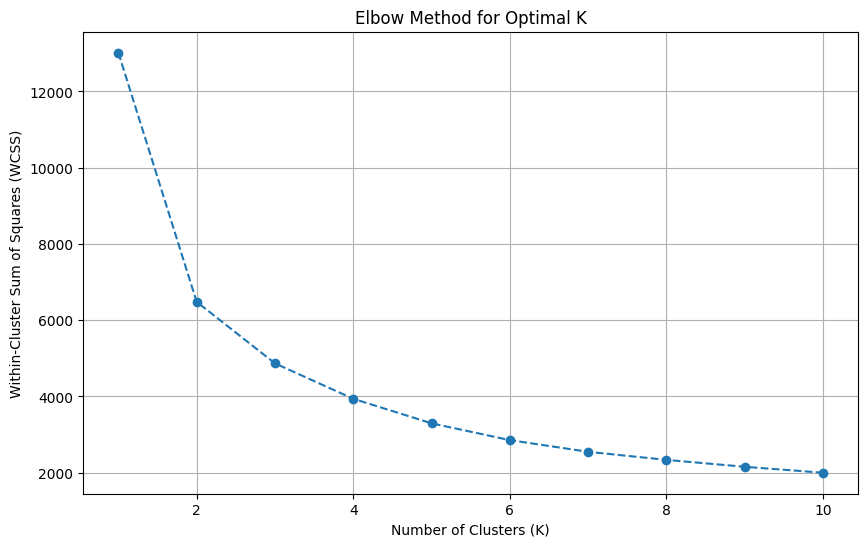

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

In [ ]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print('RFM DataFrame head:')
print(rfm_df.head())

RFM DataFrame head:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [ ]:
import numpy as np

rfm_log = rfm_df.copy()
rfm_log['Recency'] = np.log(rfm_log['Recency'] + 1)
rfm_log['Frequency'] = np.log(rfm_log['Frequency'] + 1)
rfm_log['Monetary'] = np.log(rfm_log['Monetary'] + 1)

print('RFM DataFrame after Log Transformation:')
print(rfm_log.head())

RFM DataFrame after Log Transformation:
   CustomerID   Recency  Frequency   Monetary
0     12346.0  5.789960   0.693147  11.253955
1     12347.0  1.098612   2.079442   8.368925
2     12348.0  4.330733   1.609438   7.494564
3     12349.0  2.995732   0.693147   7.472245
4     12350.0  5.739793   0.693147   5.815324


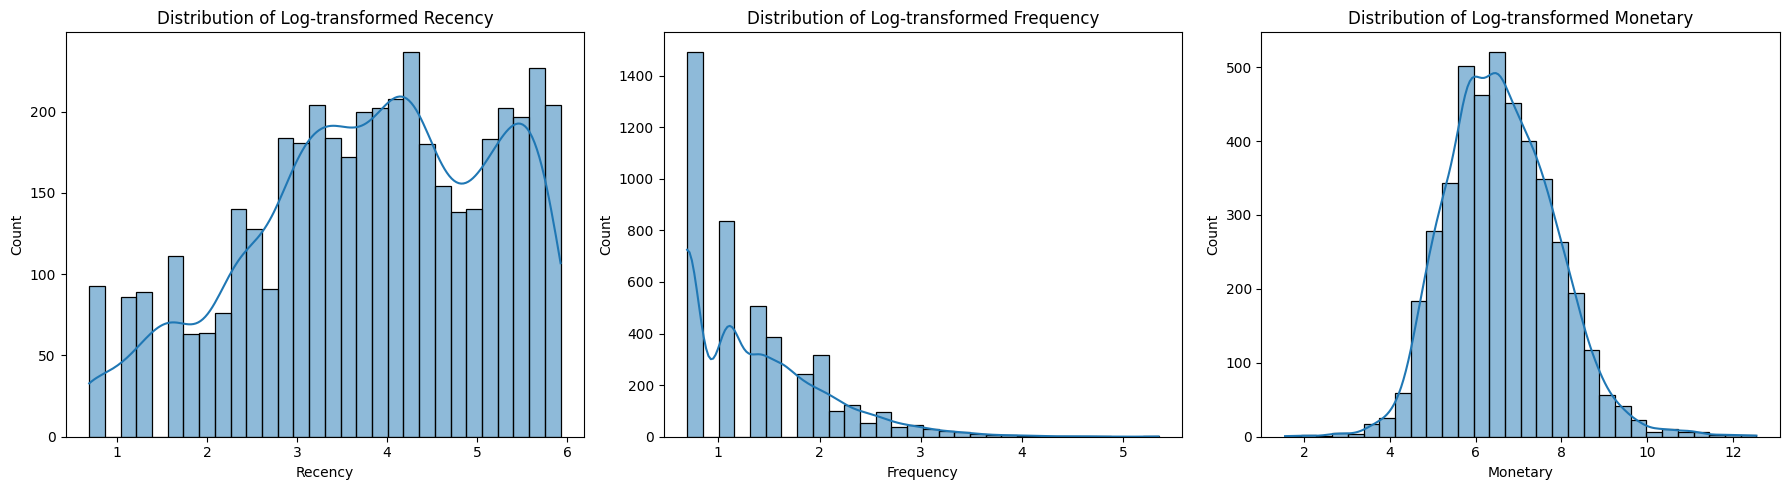

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_log['Recency'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Log-transformed Recency')

sns.histplot(rfm_log['Frequency'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Log-transformed Frequency')

sns.histplot(rfm_log['Monetary'], bins=30, kde=True, ax=ax[2])
ax[2].set_title('Distribution of Log-transformed Monetary')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('./onlineretail/OnlineRetail.csv', encoding='ISO-8859-1')

print('Original DataFrame head:')
print(df.head())

print('\nMissing values before cleaning:')
print(df.isnull().sum())

df.dropna(subset=['CustomerID'], inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('\nMissing values after cleaning:')
print(df.isnull().sum())

print('\nCleaned DataFrame head:')
print(df.head())

Original DataFrame head:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
C

In [ ]:
import pypdf

def extract_problem_from_pdf(pdf_path, problem_number):
    reader = pypdf.PdfReader(pdf_path)
    text = ''
    for page in reader.pages:
        text += page.extract_text()

    # Simple heuristic to find the problem, might need adjustment if PDF format varies
    start_marker = f'Problem {problem_number}'
    end_marker_next_problem = f'Problem {problem_number + 1}'

    start_index = text.find(start_marker)
    end_index = text.find(end_marker_next_problem)

    if start_index != -1:
        if end_index != -1 and end_index > start_index:
            problem_text = text[start_index:end_index].strip()
        else:
            problem_text = text[start_index:].strip() # If no next problem, take till end
        return problem_text
    else:
        return f'Problem {problem_number} not found.'

problem_2_description = extract_problem_from_pdf('/content/Assignment Supervised Unsupervised learning.pdf', 2)
print(problem_2_description)

Problem 2. Customer Segmentation and Purchase Prediction: 
Retail companies want to identify customer groups and predict whether a customer will make a 
high-value purchase. 
Dataset: Online Retail Dataset   https://www.kaggle.com/datasets/vijayuv/onlineretail 
Tasks: • Perform data cleaning and feature engineering (RFM features: Recency, Frequency, 
Monetary value). 
• Use K-Means clustering to segment customers. 
• Visualize clusters using PCA or t-SNE. 
• Label clusters according to customer behavior (e.g., loyal, occasional, inactive). 
• Train a supervised classifier (XGBoost or SVM) to predict high-value customers. 
• Compare model performance with and without cluster labels as features. 
…………………………………………………………………………………………………………………………………………………….
